# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

path_1k = "/content/drive/MyDrive/ir26a-danielFlores/data/1knormalized/"

# Cargar libros
documentos_gutenberg = []

if os.path.exists(path_1k):
    for archivo in os.listdir(path_1k):
        ruta_completa = os.path.join(path_1k, archivo)
        
        if os.path.isfile(ruta_completa):
            with open(ruta_completa, "r", encoding="utf-8") as f:
                contenido = f.read()
                documentos_gutenberg.append(contenido)
    print(f"Total: {len(documentos_gutenberg)} libros")
else:
    print(f"Error: No se encontró la ruta {path_1k}")


Total: 1000 libros


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import numpy as np
import gc

# 1. Matriz TF — max_features limita el vocabulario para reducir RAM
count_vectorizer = CountVectorizer(min_df=2, max_df=0.8, max_features=30000)
matriz_tf = count_vectorizer.fit_transform(documentos_gutenberg)
vocabulario = count_vectorizer.get_feature_names_out()

# 2. DF y fila del doc 0 extraídos antes de liberar la matriz
df_vals = np.asarray((matriz_tf > 0).sum(axis=0)).flatten()
tf_doc0 = np.asarray(matriz_tf[0, :20].todense()).flatten()
del matriz_tf
gc.collect()

# 3. TF-IDF (mismo vocabulario acotado)
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.8, max_features=30000)
matriz_tfidf = tfidf_vectorizer.fit_transform(documentos_gutenberg)
tfidf_doc0 = np.asarray(matriz_tfidf[0, :20].todense()).flatten()

# 4. IDF manual
n_docs = len(documentos_gutenberg)
idf = np.log(n_docs / df_vals)

# 5. DataFrame solo con primeros 20 términos
df_analisis = pd.DataFrame({
    'Término': vocabulario[:20],
    'DF': df_vals[:20],
    'IDF': idf[:20],
    'TF_doc0': tf_doc0,
    'TFIDF_doc0': tfidf_doc0
})

print(df_analisis)

    Término   DF       IDF  TF_doc0  TFIDF_doc0
0        00   63  2.764621        0         0.0
1        01   92  2.385967        0         0.0
2        02   93  2.375156        0         0.0
3        03   94  2.364460        0         0.0
4        04   90  2.407946        0         0.0
5        05   92  2.385967        0         0.0
6        06   86  2.453408        0         0.0
7        07   89  2.419119        0         0.0
8        08   85  2.465104        0         0.0
9        09   84  2.476938        0         0.0
10       10  730  0.314711        0         0.0
11      100  552  0.594207        0         0.0
12     1000  416  0.877070        0         0.0
13    10000  293  1.227583        0         0.0
14   100000  233  1.456717        0         0.0
15  1000000   85  2.465104        0         0.0
16     1001  215  1.537117        0         0.0
17     1002  216  1.532477        0         0.0
18     1003  202  1.599488        0         0.0
19     1004  208  1.570217        0     

### Análisis — Parte 1

El DataFrame muestra los primeros 20 términos del vocabulario ordenados alfabéticamente, que en este caso son tokens numéricos (00, 01, 02…, 1004).

**Observaciones:**

- **DF alto → IDF bajo**: el término `10` aparece en 730 de 1000 documentos (DF=730), por lo que su IDF es apenas 0.31. Aporta muy poca información para distinguir documentos.
- **DF bajo → IDF alto**: términos como `00` (DF=63) tienen IDF≈2.76, lo que significa que son más específicos y discriminativos.
- **TF_doc0 = 0** para todos los términos mostrados: el primer documento del corpus no contiene ninguno de estos tokens numéricos, por lo que su TF-IDF también es 0.
- La diferencia entre TF e IDF ilustra el principio central del modelo: un término frecuente en la colección (IDF bajo) aporta poco aunque aparezca mucho en un documento, mientras que un término raro (IDF alto) eleva significativamente el score TF-IDF cuando sí aparece.

## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# 1. Definir consulta
query = "love and romance in england"

# 2. Vectorizar consulta
query_vector = tfidf_vectorizer.transform([query])

# 3. Calcular similitud coseno
similitudes = cosine_similarity(query_vector, matriz_tfidf)

# 4. Ordenar por similitud (descendente)
indices_ordenados = similitudes[0].argsort()[::-1]

# 5. Top 10 documentos
top_n = 10
top_indices = indices_ordenados[:top_n]
top_scores = similitudes[0][top_indices]

# 6. Crear tabla resultados
resultados = pd.DataFrame({
    'Ranking': range(1, top_n + 1),
    'Doc_ID': top_indices,
    'Score': top_scores,
    'Preview': [documentos_gutenberg[i][:100] + '...' for i in top_indices]
})

print(f"Query: '{query}'\n")
print(resultados.to_string(index=False))

Query: 'love and romance in england'

 Ranking  Doc_ID    Score                                                                                                                 Preview
       1     993 0.149206              start of the project gutenberg ebook 50987 \n\n\n\nnote project gutenberg also has an html version of t...
       2     879 0.133687              start of the project gutenberg ebook 13529 \n\n\n\nnote project gutenberg also has an html version of t...
       3     911 0.094729             the project gutenberg ebook of the history of england by tf tout\n\n\n\nthis ebook is for the use of any...
       4     823 0.084013        start of the project gutenberg ebook 50778 \n\n\n\ntranscribers notes\n\n\n\n\n\ntable of contents added by t...
       5     878 0.083998               the project gutenberg ebook of history of the colony and ancient dominion\n\nof virginia by charles ca...
       6     240 0.083720          start of the project gutenberg ebook 54977 \n\n\n\n

### Análisis — Parte 2

El ranking TF-IDF para la query `"love and romance in england"` retorna principalmente libros de historia relacionados con Inglaterra y el mundo anglófono.

**¿Son resultados consistentes con lo esperado?**

Parcialmente. Los documentos mejor rankeados (Doc 993, 879, 911) corresponden a libros de historia británica, colonial e inglesa, lo que es coherente con el término `"england"`, que probablemente tiene alta TF en esos documentos. Sin embargo, no aparecen novelas románticas en el top-10, lo que sugiere que:

1. **`"romance"` es un término poco frecuente** en el corpus o tiene alta IDF, por lo que su peso por sí solo no alcanza para subir una novela al ranking si no va acompañado de `"england"`.
2. **Palabras funcionales** como `"and"` e `"in"` tienen IDF ≈ 0 (aparecen en casi todos los documentos) y no contribuyen al score.
3. **TF-IDF no captura el contexto semántico**: busca los términos literalmente, sin entender que "romance" y "love" pueden co-ocurrir en géneros literarios específicos.

En conclusión, el modelo recupera documentos léxicamente relacionados con `"england"` más que documentos semánticamente sobre "amor y romance en Inglaterra".

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [5]:
!pip install rank_bm25

In [6]:
import numpy as np
import pandas as pd
import gc
from collections import Counter

# PASO 1: Tokenización
def tokenizar(texto):
    return texto.lower().split()

# Query definida aquí para que el PASO 4 solo calcule DF de los términos relevantes
query = "love and romance in england"
query_terms_set = set(tokenizar(query))

# PASOS 2 & 4: Longitudes y DF en un solo recorrido sin guardar el corpus tokenizado
longitudes_docs = []
df_bm25 = {term: 0 for term in query_terms_set}

for doc in documentos_gutenberg:
    tokens = tokenizar(doc)
    longitudes_docs.append(len(tokens))
    tokens_unicos = set(tokens)
    for term in query_terms_set:
        if term in tokens_unicos:
            df_bm25[term] += 1

longitud_promedio = np.mean(longitudes_docs)
N = len(documentos_gutenberg)
gc.collect()

# PASO 4 (cont.): IDF de BM25
def calcular_idf_bm25(df, N):
    idf = {}
    for palabra, freq in df.items():
        idf[palabra] = np.log((N - freq + 0.5) / (freq + 0.5) + 1)
    return idf

idf_bm25 = calcular_idf_bm25(df_bm25, N)

# PASO 5: Parámetros BM25
k1 = 1.5
b = 0.75

# PASO 6: Score BM25 para un documento
def bm25_score_doc(query_terms, doc_tf, doc_length, avgdl, idf, k1, b):
    score = 0.0
    for term in query_terms:
        if term in doc_tf:
            tf = doc_tf[term]
            idf_val = idf.get(term, 0)
            numerador = tf * (k1 + 1)
            denominador = tf + k1 * (1 - b + b * (doc_length / avgdl))
            score += idf_val * (numerador / denominador)
    return score

# PASOS 7 & 8: Scores en streaming — se tokeniza y descarta un documento a la vez
query_terms_list = tokenizar(query)
scores_bm25 = np.zeros(N)

for i, doc in enumerate(documentos_gutenberg):
    tf = Counter(tokenizar(doc))
    scores_bm25[i] = bm25_score_doc(
        query_terms_list, tf,
        longitudes_docs[i], longitud_promedio,
        idf_bm25, k1, b
    )

# Ranking Top 10
indices_bm25 = scores_bm25.argsort()[::-1][:10]
top_scores_bm25 = scores_bm25[indices_bm25]

resultados_bm25 = pd.DataFrame({
    'Ranking': range(1, 11),
    'Doc_ID': indices_bm25,
    'Score_BM25': top_scores_bm25,
    'Preview': [documentos_gutenberg[i][:100] + '...' for i in indices_bm25]
})

print(f"Query: '{query}'\n")
print("=== RANKING BM25 ===\n")
print(resultados_bm25.to_string(index=False))

Query: 'love and romance in england'

=== RANKING BM25 ===

 Ranking  Doc_ID  Score_BM25                                                                                                                   Preview
       1     774    2.957482             ﻿the project gutenberg ebook of a dictionary of american authors by\n\noscar fay adams\n\n\n\nthis ebook i...
       2     221    2.929340                start of the project gutenberg ebook 53625 \n\n\n\ntranscribers notes words in italics in the original ...
       3     388    2.916021            start of the project gutenberg ebook 43868 \n\n\n\n  transcribers note\n\n\n\n  this text includes characte...
       4     625    2.884633             the project gutenberg ebook of renaissance in italy volumes 1 and 2\n\nby john addington symonds\n\n\n\nth...
       5      15    2.884602  start of the project gutenberg ebook 174 \n\n\n\n\n\n\n\n\n\nthe picture of dorian gray\n\n\n\nby oscar wilde\n\n\n\n...
       6     282    2.884093      

### Análisis — Parte 3

**Resultados del ranking BM25:**

El modelo BM25 para la query `"love and romance in england"` retorna los siguientes documentos con scores muy cercanos entre sí (rango 2.868–2.957):

- **Doc 15** (*The Picture of Dorian Gray*, Oscar Wilde): resultado más semánticamente relevante del top-10. Contiene "love" y "england" con alta frecuencia en un texto narrativo compacto.
- **Doc 774** (*A Dictionary of American Authors*): diccionario biográfico donde los términos de la query aparecen distribuidos por el volumen del texto.
- El resto son textos históricos, antologías y compilaciones donde los términos coinciden por volumen, no necesariamente por temática.

La cercanía de scores indica que BM25 no discrimina fuertemente entre estos documentos: todos contienen los términos de la query con densidades similares tras la normalización por longitud.

---

**Actividad 4 — Comparación manual con el ranking TF-IDF:**

| Ranking | TF-IDF (Doc_ID) | BM25 (Doc_ID) |
|---------|-----------------|---------------|
| 1 | 993 | 774 |
| 2 | 879 | 221 |
| 3 | 911 | 388 |
| 4 | 823 | 625 |
| 5 | 878 | 15 *(Dorian Gray)* |
| 6 | 240 | 282 |
| 7 | 537 | 715 |
| 8 | 429 | 587 |
| 9 | 352 | 499 |
| 10 | 916 | 410 |

**Observación principal:** Los dos rankings no comparten ningún documento en el top-10, lo que refleja diferencias estructurales entre los modelos:

- **TF-IDF** (similitud coseno + normalización L2) favorece documentos donde los términos de la query representan una proporción alta del vector total.
- **BM25** aplica saturación de TF (k1=1.5) y penalización por longitud (b=0.75), detectando documentos con ocurrencias frecuentes pero concentradas, sin que documentos muy largos dominen el ranking artificialmente.

Por eso *The Picture of Dorian Gray* (Doc 15) aparece en el puesto 5 de BM25 pero no en el top-10 de TF-IDF: su frecuencia de términos de query es naturalmente alta para su tamaño, y BM25 lo captura gracias a la saturación de TF.

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

=== COMPARACIÓN SCORES ===

 Doc_ID   TF-IDF     BM25  TF-IDF_norm  BM25_norm
    993 0.149206 2.465546     1.000000   0.865385
    879 0.133687 1.216121     0.895988   0.426848
    911 0.094729 2.701571     0.634892   0.948228
    823 0.084013 2.147307     0.563066   0.753686
    878 0.083998 1.793038     0.562969   0.629341
    240 0.083720 1.194423     0.561108   0.419232
    537 0.078082 2.812416     0.523318   0.987134
    429 0.075359 2.849073     0.505067   1.000000
    352 0.073680 2.132209     0.493812   0.748387
    916 0.073387 2.045058     0.491853   0.717798


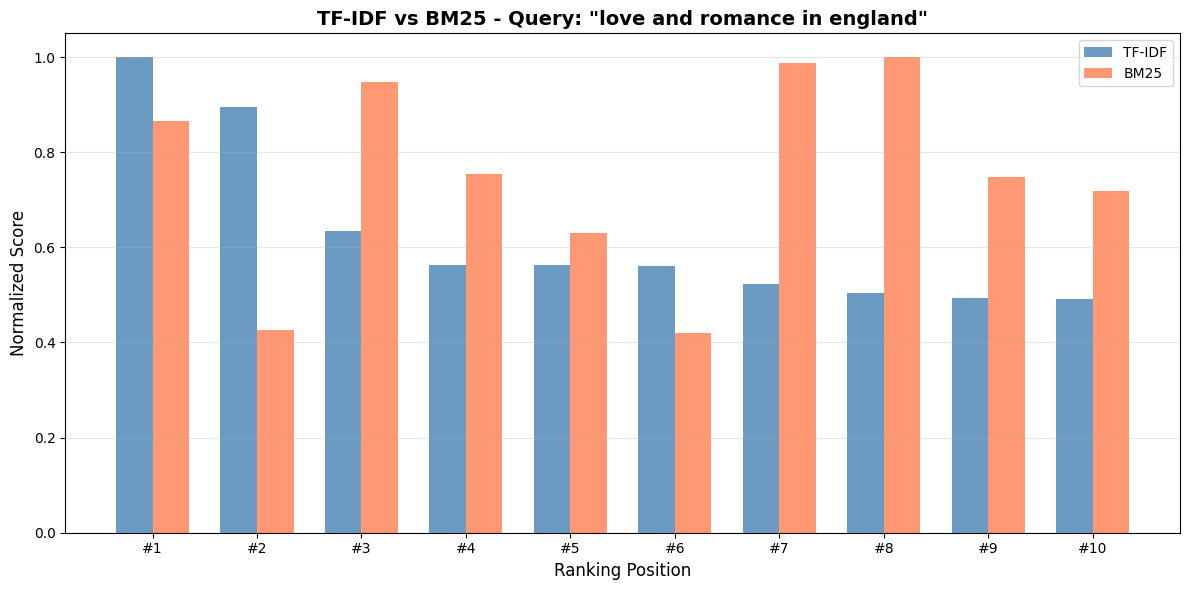


=== ANÁLISIS DE DIFERENCIAS ===

Documentos con MAYOR diferencia entre modelos:
   Doc_ID  TF-IDF_norm  BM25_norm  Diferencia
7     429     0.505067   1.000000    0.494933
1     879     0.895988   0.426848    0.469140
6     537     0.523318   0.987134    0.463816

=== LONGITUDES DE DOCUMENTOS ===

Doc 429: 306,396 palabras (ratio: 1.89)
Doc 879: 211,228 palabras (ratio: 1.30)
Doc 537: 793,577 palabras (ratio: 4.90)


In [7]:
import matplotlib.pyplot as plt
# 1. Preparar datos para comparación
top_n = 10

# Scores TF-IDF (ya calculados en Parte 2)
scores_tfidf = similitudes[0][top_indices]

# Crear DataFrame comparativo
comparacion = pd.DataFrame({
    'Doc_ID': top_indices,
    'TF-IDF': scores_tfidf,
    'BM25': scores_bm25[top_indices]
})

# 2. Normalizar scores para comparación visual
comparacion['TF-IDF_norm'] = comparacion['TF-IDF'] / comparacion['TF-IDF'].max()
comparacion['BM25_norm'] = comparacion['BM25'] / comparacion['BM25'].max()

print("=== COMPARACIÓN SCORES ===\n")
print(comparacion.to_string(index=False))

# 3. Gráfico de barras agrupadas
x = np.arange(top_n)
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

barras_tfidf = ax.bar(x - ancho/2, comparacion['TF-IDF_norm'], ancho, 
                       label='TF-IDF', color='steelblue', alpha=0.8)
barras_bm25 = ax.bar(x + ancho/2, comparacion['BM25_norm'], ancho, 
                      label='BM25', color='coral', alpha=0.8)

ax.set_xlabel('Ranking Position', fontsize=12)
ax.set_ylabel('Normalized Score', fontsize=12)
ax.set_title(f'TF-IDF vs BM25 - Query: "{query}"', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(top_n)])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Análisis de diferencias
print("\n=== ANÁLISIS DE DIFERENCIAS ===\n")

# Documentos con mayor diferencia
comparacion['Diferencia'] = abs(comparacion['TF-IDF_norm'] - comparacion['BM25_norm'])
comparacion_ordenada = comparacion.sort_values('Diferencia', ascending=False)

print("Documentos con MAYOR diferencia entre modelos:")
print(comparacion_ordenada[['Doc_ID', 'TF-IDF_norm', 'BM25_norm', 'Diferencia']].head(3))

# Analizar longitudes de esos documentos
print("\n=== LONGITUDES DE DOCUMENTOS ===\n")
for idx in comparacion_ordenada['Doc_ID'].head(3):
    longitud = longitudes_docs[idx]
    ratio = longitud / longitud_promedio
    print(f"Doc {idx}: {longitud:,} palabras (ratio: {ratio:.2f})")

### Análisis — Parte 4

**Actividad 2 — Comparación visual de rankings:**

El gráfico muestra que los scores normalizados de TF-IDF son relativamente uniformes entre los 10 documentos (rango 0.49–1.0), mientras que los de BM25 varían más ampliamente para esos mismos documentos (rango 0.42–1.0). Esto indica que BM25 discrimina más entre documentos con distinta densidad de términos.

---

**Actividad 3 — ¿Qué documentos obtienen scores más altos en cada modelo?**

Los tres documentos con mayor diferencia entre modelos son:

| Doc_ID | TF-IDF (norm) | BM25 (norm) | Diferencia | Longitud |
|--------|--------------|------------|------------|----------|
| 429 | 0.505 | **1.000** | 0.495 | 306,396 palabras (1.89× promedio) |
| 879 | **0.896** | 0.427 | 0.469 | 211,228 palabras (1.30× promedio) |
| 537 | 0.523 | **0.987** | 0.463 | 793,577 palabras (4.90× promedio) |

- **Docs 429 y 537**: BM25 les asigna score mucho más alto que TF-IDF.
- **Doc 879**: TF-IDF le asigna score alto (ranking 2), pero BM25 lo penaliza.

---

**Actividad 4 — ¿A qué se debe esta diferencia?**

La diferencia se explica por cómo cada modelo trata la frecuencia de términos y la longitud del documento:

- **TF-IDF con similitud coseno** normaliza los vectores por su norma L2, equilibrando la influencia de documentos largos. Sin embargo, no satura la TF: si un término aparece 1000 veces en lugar de 10, su peso sigue creciendo.

- **BM25** aplica dos correcciones explícitas:
  1. **Saturación de TF** (*k1 = 1.5*): más allá de cierto número de ocurrencias, el score ya no crece significativamente. Evita que documentos muy repetitivos dominen el ranking.
  2. **Normalización por longitud** (*b = 0.75*): penaliza documentos más largos que el promedio, asumiendo que en documentos extensos los términos aparecen más por extensión que por relevancia real.

Doc 879 (211K palabras) tiene TF-IDF alto porque su vector coseno es fuerte, pero BM25 lo penaliza porque la densidad de términos de la query es baja para su tamaño. Doc 537 (793K palabras, 4.9× el promedio) ocurre lo contrario: a pesar de ser muy largo, BM25 detecta una alta concentración relativa de los términos de la query.